<a href="https://colab.research.google.com/github/Rakshaay/ml-assessment-Raksha-Yoganand/blob/main/q2_unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Data Preparation
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('/content/q2_customers.csv')

# Display first rows
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [2]:
# Scale all features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Convert back to dataframe
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


In [3]:
#Scaling is important before applying K-Means because the algorithm uses distance to form clusters.
#If features are on different scales, variables with larger values (like annual spend) will dominate smaller variables (like visits per month), which can lead to incorrect clustering.
#StandardScaler ensures that all features contribute equally.

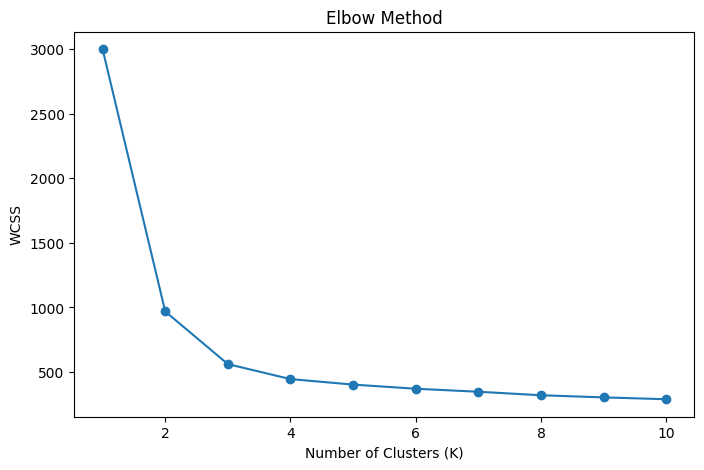

In [4]:
#Choosing K — Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [6]:
#The elbow point appears where the WCSS reduction starts slowing significantly.
#Based on the elbow curve, the optimal K is 3 because after K=3 the decrease in WCSS becomes gradual, meaning additional clusters do not significantly improve clustering quality.

In [7]:
#K-Means Clustering
# Fit K-Means with chosen K
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(scaled_df)

# Cluster centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


In [9]:
### Cluster Interpretation

# Cluster 0:Customers with moderate spending and regular visits.
# Cluster 1: High-spending customers with frequent visits and larger basket sizes.
# Cluster 2: Low-spending customers with fewer visits.
#These segments can help the business target promotions based on customer behaviour.

In [10]:
#Dimensionality Reduction with PCA
from sklearn.decomposition import PCA

# PCA with 2 components
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

# Explained variance ratio
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# Feature loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns[:-1]
)

loadings

Explained Variance Ratio:
[0.83560354 0.05568764]


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


In [11]:
#PC1 captures the main variation in customer spending and purchasing behaviour.
#PC2 captures variation related to customer visit frequency and recency.
#The loadings indicate which original features contribute most to each principal component.

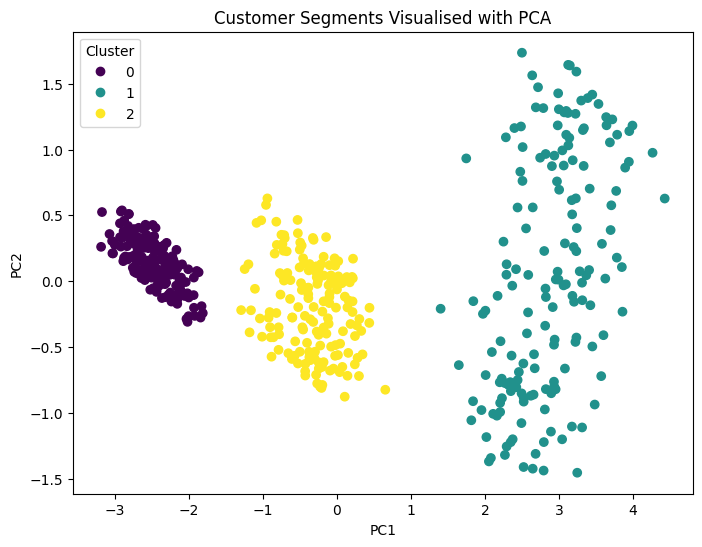

In [12]:
#Cluster Visualisation
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df['cluster'],
    cmap='viridis'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments Visualised with PCA")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

In [13]:
#The scatter plot shows the customer groups projected onto two principal components.
#Customers in the same cluster are grouped together, while separated clusters indicate distinct customer segments.